Total photons that scattered at least once: 47104


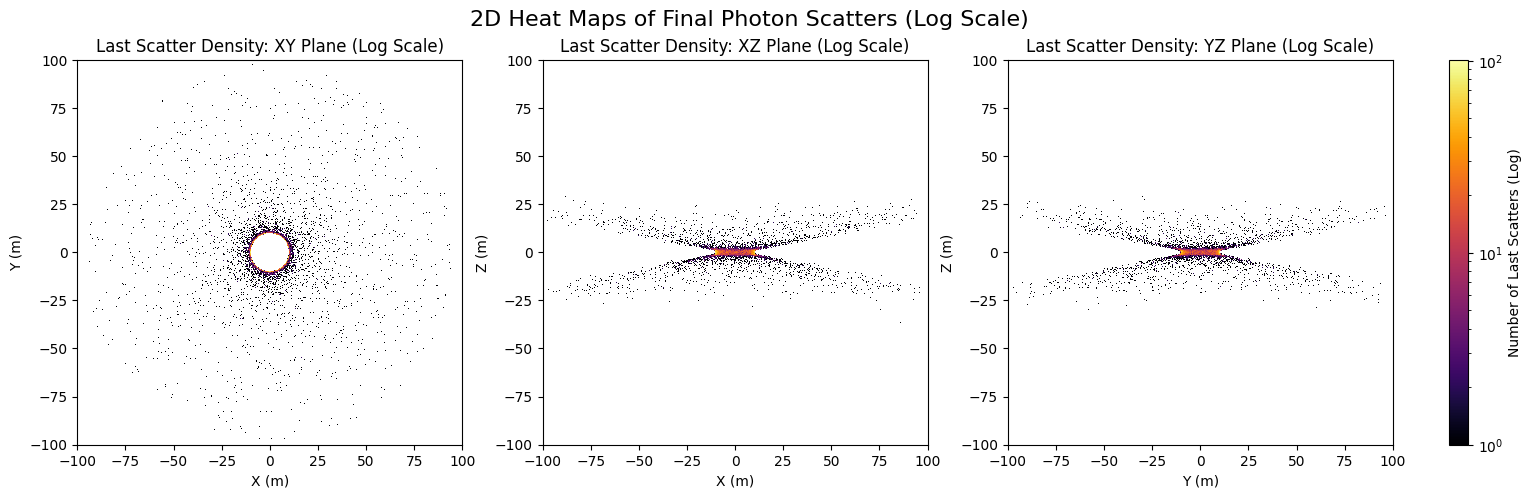

In [18]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import plotly.express as px

# --- 1. Load the Data ---
# Using your specific file path and tree structure
file_path = "/Users/sanderkatz/Documents/UCBResearch/code/C++/PHYS207Project/geant4/data.root"
data = uproot.open(file_path)
output = data['Scatters;1']

# Extract arrays
trackX = output['fX'].array(library="np")
trackY = output['fY'].array(library="np")
trackZ = output['fZ'].array(library="np")
event = output['event_id'].array(library="np")

# Combine into a Pandas DataFrame
df = pd.DataFrame({
    'x': trackX,
    'y': trackY,
    'z': trackZ,
    'event_id': event
})

# --- 2. Filter for the Last Scatter ---
# Group by event_id and take the last row for each photon.
# This ensures we are only looking at the final scatter location.
last_scatters = df.groupby('event_id').tail(1).copy()

print(f"Total photons that scattered at least once: {len(last_scatters)}")

# --- 3. Plot 2D Heatmaps (XY, XZ, YZ) in Log Scale ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmap = 'inferno' 
bins = 1000
range_lim = [[-100, 100], [-100, 100]] # Fixed to simulation boundary

# XY Plane
axes[0].hist2d(last_scatters['x'], last_scatters['y'], bins=bins, range=range_lim, cmap=cmap, norm=LogNorm())
axes[0].set_title('Last Scatter Density: XY Plane (Log Scale)')
axes[0].set_xlabel('X (m)')
axes[0].set_ylabel('Y (m)')
axes[0].set_aspect('equal')

# XZ Plane
axes[1].hist2d(last_scatters['x'], last_scatters['z'], bins=bins, range=range_lim, cmap=cmap, norm=LogNorm())
axes[1].set_title('Last Scatter Density: XZ Plane (Log Scale)')
axes[1].set_xlabel('X (m)')
axes[1].set_ylabel('Z (m)')
axes[1].set_aspect('equal')

# YZ Plane
h = axes[2].hist2d(last_scatters['y'], last_scatters['z'], bins=bins, range=range_lim, cmap=cmap, norm=LogNorm())
axes[2].set_title('Last Scatter Density: YZ Plane (Log Scale)')
axes[2].set_xlabel('Y (m)')
axes[2].set_ylabel('Z (m)')
axes[2].set_aspect('equal')

# Add a colorbar
fig.colorbar(h[3], ax=axes, label='Number of Last Scatters (Log)', fraction=0.015, pad=0.04)
plt.suptitle('2D Heat Maps of Final Photon Scatters (Log Scale)', fontsize=16)
plt.show()

# --- 4. Plot 3D Interactive Scatter with Plotly (Density Colored + Small Dots) ---
# Sample data for performance if needed
sample_size = 50000
if len(last_scatters) > sample_size:
    print(f"Sampling down to {sample_size} points for smoother 3D rendering...")
    plot_df = last_scatters.sample(n=sample_size, random_state=42).copy()
else:
    plot_df = last_scatters.copy()

# Fast 3D density calculation for color coding
density_bins = 30
H, edges = np.histogramdd(plot_df[['x', 'y', 'z']].values, bins=density_bins)
idx_x = np.clip(np.digitize(plot_df['x'], edges[0]) - 1, 0, density_bins - 1)
idx_y = np.clip(np.digitize(plot_df['y'], edges[1]) - 1, 0, density_bins - 1)
idx_z = np.clip(np.digitize(plot_df['z'], edges[2]) - 1, 0, density_bins - 1)
plot_df['density'] = H[idx_x, idx_y, idx_z]

# Create the base 3D scatter plot
fig_3d = px.scatter_3d(
    plot_df, 
    x='x', y='y', z='z',
    color='density',
    color_continuous_scale='Inferno',
    opacity=0.6,
    title="3D Visualization of Final Photon Scatters (Colored by Density)"
)

# --- CHANGE HERE: Make dots smaller ---
# Set size to 1 (pixel radius). Increase slightly if they are too small to see.
fig_3d.update_traces(marker=dict(size=1)) 
# -------------------------------------

# Force the 3D axes to properly reflect the 200m boundaries and maintain aspect ratio
fig_3d.update_layout(
    scene=dict(
        xaxis=dict(range=[-200, 200], title='X (m)'),
        yaxis=dict(range=[-200, 200], title='Y (m)'),
        zaxis=dict(range=[-200, 200], title='Z (m)'),
        aspectmode='cube' 
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig_3d.show()

In [11]:
print(len(trackX))

77680


In [13]:
print(event)

[2134, 2145, 2145, 2152, 2152, ..., 497010, 497010, 497010, 497019, 497019]
